# EUFLOW




## Data

For this project, we will use the following datasets obtained from Eurostat:

- **tour_dem_extotw**  
  Expenditure by detailed country or world region of the main destination of the trip.

- **tour_dem_tnac**  
  Nights spent by the main mode of accommodation.

- **tour_dem_ttw**  
  Trips by detailed country or world region of the main destination.

- **tour_occ_arnraw**  
  Arrivals at tourist accommodation establishments by the country of origin of the tourist.

- **tour_dem_tnws**  
  Nights spent by activity status of the tourist.

- **tour_dem_tnw**  
  Nights spent by detailed country or world region of the main destination of the trip.

- **tour_dem_ttws**  
  Trips by activity status of the tourist.

- **tour_dem_tttr**  
  Trips by the main mode of transport.

All datasets can be downloaded from the Eurostat bulk database:

[Eurostat Bulk Data Download](https://ec.europa.eu/eurostat/databrowser/bulk?lang=en)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Expenditure by detailed country or world region of the main destination of the trip.
extotw = pd.read_table('data/estat_tour_dem_extotw.tsv')

# Nights spent by the main mode of accommodation.
tnac = pd.read_table('data/estat_tour_dem_tnac.tsv')

# Trips by detailed country or world region of the main destination.
ttw = pd.read_table('data/estat_tour_dem_ttw.tsv')

# Nights spent by detailed country or world region of the main destination of the trip.
tnw = pd.read_table('data/estat_tour_dem_tnw.tsv')

# Arrivals at tourist accommodation establishments by the country of origin of the tourist.
arnraw = pd.read_table('data/estat_tour_occ_arnraw.tsv')

# Trips by activity status of the tourist.
ttws = pd.read_table('data/estat_tour_dem_ttws.tsv')

# Nights spent by activity status of the tourist.
tnws = pd.read_table('data/estat_tour_dem_tnws.tsv')

# Trips by the main mode of transport.
tttr = pd.read_table('data/estat_tour_dem_tttr.tsv')

### Cleaning of the data 

In [3]:
def clean_df(df, dropna=False, columns_drop=None):
    """Clean the dataframe by splitting the first column into multiple columns and converting the remaining columns to numeric values."""
    df = df.copy()
    columns = df.columns
    new_columns = columns[0].split(',')
    
    n_col = df[columns[0]].str.split(',', expand=True)
    n_col.columns = new_columns
    df = pd.concat([n_col, df], axis=1)
    df = df.drop(columns=[columns[0]])
    df[columns[1:]] = df[columns[1:]].apply(lambda s: s.str.replace(':', ''))
    df[columns[1:]] = df[columns[1:]].apply(lambda s: s.str.replace('u', ''))
    df[columns[1:]] = df[columns[1:]].apply(lambda s: s.str.replace('b', ''))
    df[columns[1:]] = df[columns[1:]].apply(lambda s: s.str.replace('e', ''))
    df[columns[1:]] = df[columns[1:]].apply(lambda s: pd.to_numeric(s, errors='coerce'))
    if dropna:
        df = df.dropna()
    if columns_drop is not None:
        df = df.drop(columns=columns_drop)
    return df, columns[1:], df['geo'].unique()

In [4]:
extotw_cleaned, years_extotw, geo_extotw = clean_df(extotw, dropna=True, columns_drop=['unit', 'freq'])
tnac_cleaned, years_tnac, geo_tnac = clean_df(tnac, dropna=True, columns_drop=['freq', 'unit'])
ttw_cleaned, years_ttw, geo_ttw = clean_df(ttw, dropna=True, columns_drop=['unit', 'freq'])
tnw_cleaned, years_tnw, geo_tnw = clean_df(tnw, dropna=True, columns_drop=['unit', 'freq'])
arnraw_cleaned, years_arnraw, geo_arnraw = clean_df(arnraw, dropna=True, columns_drop=['unit', 'freq'])
ttws_cleaned, years_ttws, geo_ttws = clean_df(ttws, dropna=True, columns_drop=['unit', 'freq'])
tnws_cleaned, years_tnws, geo_tnws = clean_df(tnws, dropna=True, columns_drop=['unit', 'freq'])
tttr_cleaned, years_tttr, geo_tttr = clean_df(tttr, dropna=True, columns_drop=['unit', 'freq'])

eu_countries = extotw_cleaned['geo'].unique()

In [5]:
# Save cleaned dataframes to new CSV files
extotw_cleaned.to_csv('data/cleaned_extotw.csv', index=False)
tnac_cleaned.to_csv('data/cleaned_tnac.csv', index=False)
ttw_cleaned.to_csv('data/cleaned_ttw.csv', index=False)
tnw_cleaned.to_csv('data/cleaned_tnw.csv', index=False)
arnraw_cleaned.to_csv('data/cleaned_arnraw.csv', index=False)
ttws_cleaned.to_csv('data/cleaned_ttws.csv', index=False)
tnws_cleaned.to_csv('data/cleaned_tnws.csv', index=False)
tttr_cleaned.to_csv('data/cleaned_tttr.csv', index=False)

## Expenditure of Tourists

### Dataset Description (**tour_dem_extot**)

We start by explaining the dataset **tour_dem_extotw**, first let's have a look at the cleaned dataset:

In [6]:
extotw_cleaned.head(10)

,purpose,duration,c_dest,expend,statinfo,geo,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
980,PER,N1-3,AME,ACCOM,AVG_NGT,EA20,55.20,86.73,66.99,70.61,26.34,63.91,48.80,78.76,55.54,62.88,38.27,77.48,58.97
984,PER,N1-3,AME,ACCOM,AVG_NGT,EU27_2020,52.87,68.03,70.69,71.06,29.70,65.22,49.57,74.26,43.18,61.51,44.45,77.41,55.95
1010,PER,N1-3,AME,ACCOM,AVG_TRP,EA20,154.08,212.71,141.92,167.72,72.91,119.32,129.48,196.27,117.92,170.35,93.99,184.13,143.77
1014,PER,N1-3,AME,ACCOM,AVG_TRP,EU27_2020,143.92,158.11,147.49,161.31,76.05,123.05,131.63,188.67,98.93,168.29,105.36,181.01,127.31
1040,PER,N1-3,AME,DUR,AVG_NGT,EA20,9.85,15.20,37.53,5.82,247.28,30.30,0.80,0.68,0.00,9.80,0.00,2.56,0.00
1044,PER,N1-3,AME,DUR,AVG_NGT,EU27_2020,9.15,12.90,34.30,6.32,214.81,27.59,0.79,10.03,0.00,12.27,0.00,2.51,4.28
1070,PER,N1-3,AME,DUR,AVG_TRP,EA20,27.48,37.29,79.50,13.83,684.46,56.58,2.12,1.69,0.00,26.55,0.00,6.08,0.00
1074,PER,N1-3,AME,DUR,AVG_TRP,EU27_2020,24.90,29.98,71.56,14.35,550.03,52.05,2.11,25.48,0.00,33.58,0.00,5.86,9.74
1225,PER,N1-3,AME,TOTXDUR,AVG_NGT,EA20,991.06,263.44,375.19,307.86,186.53,331.25,365.94,835.60,369.58,385.51,422.67,342.96,485.42
1229,PER,N1-3,AME,TOTXDUR,AVG_NGT,EU27_2020,933.00,220.52,372.25,327.94,191.48,337.14,367.42,840.98,353.72,368.00,408.14,339.44,460.80



This dataset provides tourism statistics describing travel behavior based on several dimensions related to the origin of the traveler, the destination of the trip, and the characteristics of the trip itself.

The variable **`geo`** represents the country of residence of the tourist (for example: Germany, France, Spain) as well as aggregated regions such as the **Euro Area (EA20)** or the **European Union (EU27_2020)**.

The variable **`c_dest`** indicates the **destination of the trip**, which may correspond to specific countries (e.g., **US, CN, BR, CH**) or aggregated geographic regions (e.g., **EUR, AFR, AME, ASI, WORLD**).

The **`purpose`** variable describes the **main reason for the trip**, distinguishing between **personal travel (PER)**, **professional or business travel (PROF)**, and **total trips (TOTAL)**.

The **`Duration`** variable classifies trips according to the **number of nights spent**:
- **N1-3**: trips lasting between 1 and 3 nights  
- **N_GE4**: trips lasting 4 nights or more  
- **N_GE1**: all trips with at least one overnight stay  

The **`Statinfo`** variable specifies the type of statistic reported in the dataset:
- **AVG_NGT**: average number of nights spent  
- **AVG_TRP**: average number of trips  
- **TOTAL**: total number of trips or nights  

Finally, the **year columns** represent the **values of these statistics over time**, showing how the number of trips, nights, or averages evolve for each combination of the other parameters (country of residence, destination, purpose of travel, duration, and statistic type).


The dataset uses geographic codes to represent both **countries** and **aggregated regions**.  
The following table provides the unified translation of all geographic codes appearing in the dataset.

| Code | Country / Region |
|-----|------------------|
| EA20 | Euro Area (20 countries) |
| EU27_2020 | European Union (27 countries, post-2020) |
| AT | Austria |
| BE | Belgium |
| BG | Bulgaria |
| BR | Brazil |
| CA | Canada |
| CH | Switzerland |
| CN | China |
| CY | Cyprus |
| CZ | Czechia |
| DE | Germany |
| DK | Denmark |
| DOM | Dominican Republic |
| EE | Estonia |
| EL | Greece |
| ES | Spain |
| FI | Finland |
| FR | France |
| HR | Croatia |
| HU | Hungary |
| IE | Ireland |
| IS | Iceland |
| IT | Italy |
| LT | Lithuania |
| LU | Luxembourg |
| LV | Latvia |
| MT | Malta |
| NL | Netherlands |
| NO | Norway |
| PL | Poland |
| PT | Portugal |
| RO | Romania |
| RU | Russia |
| SE | Sweden |
| SI | Slovenia |
| SK | Slovakia |
| TR | Türkiye |
| UA | Ukraine |
| UK | United Kingdom |
| US | United States |
| ZA | South Africa |
| AFR | Africa |
| AFR_OTH | Other African countries |
| AME | America |
| AME_N | North America |
| AME_C_S | Central and South America |
| AME_C_S_OTH | Other Central and South American countries |
| ASI | Asia |
| ASI_OTH | Other Asian countries |
| EUR | Europe |
| EUR_OTH | Other European countries |
| EFTA | European Free Trade Association |
| FOR | Foreign countries |
| EU27_2020_FOR | EU27 destinations excluding the country of residence |
| WORLD | Worldwide |

### 

### Data analysis

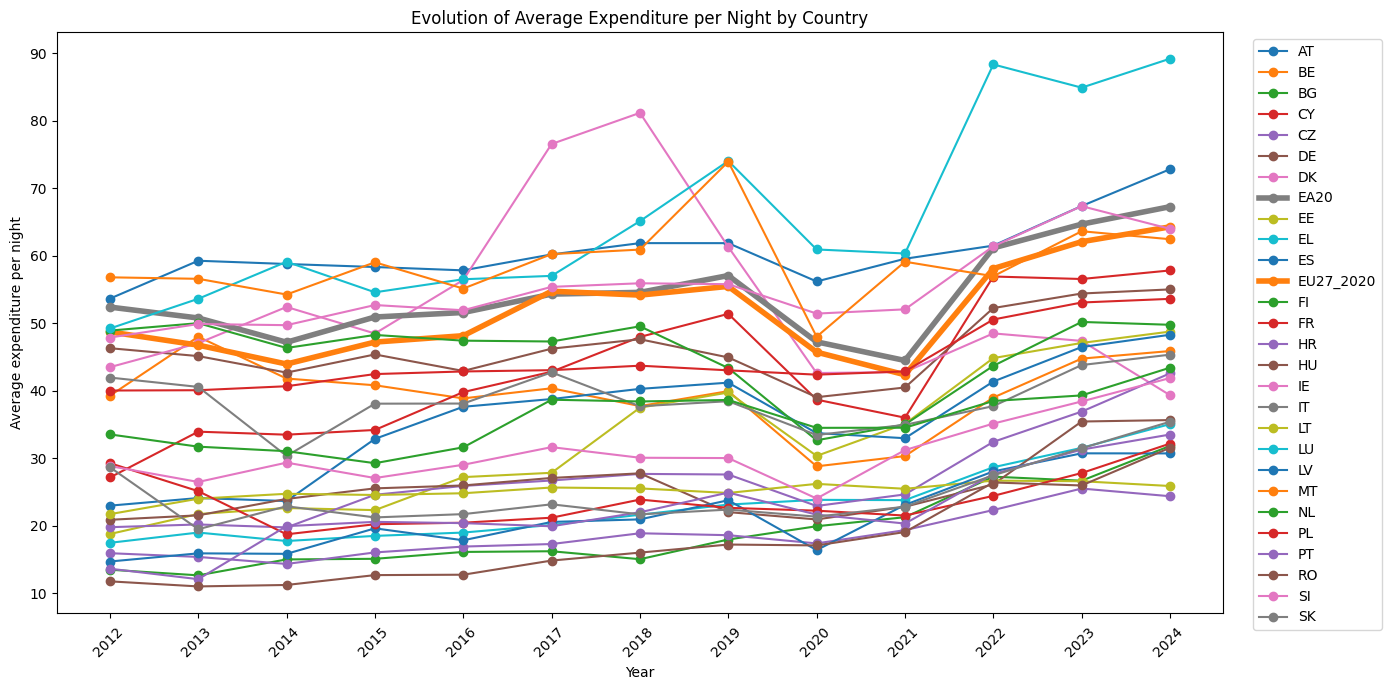

In [7]:
# Average expenditure per night by country per
avg_expenditure_night = extotw_cleaned[extotw_cleaned['statinfo'] == 'AVG_NGT']
avg_spending_per_country = avg_expenditure_night.groupby('geo')[years_extotw].mean()


plt.figure(figsize=(14, 7))

highlighted_countries = ['EA20', 'EU27_2020']

for country in avg_spending_per_country.index:
    if country in highlighted_countries:
        plt.plot(
            avg_spending_per_country.columns,
            avg_spending_per_country.loc[country],
            marker="o",
            linewidth=4,
            label=country
        )
    else:
        plt.plot(
            avg_spending_per_country.columns,
            avg_spending_per_country.loc[country],
            alpha=1,
            marker="o",
            label=country
        )

plt.title("Evolution of Average Expenditure per Night by Country")
plt.xlabel("Year")
plt.ylabel("Average expenditure per night")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

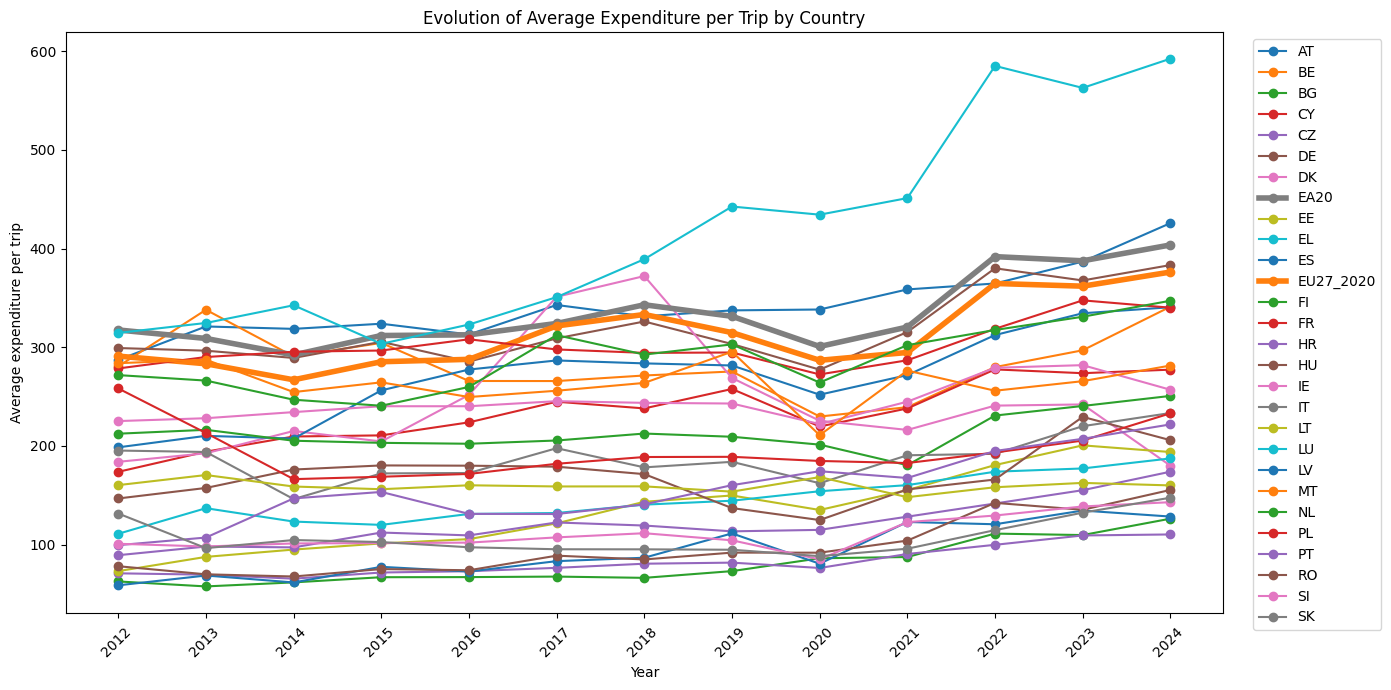

In [8]:
# Average expenditure per trip by country
avg_expenditure_trip = extotw_cleaned[extotw_cleaned['statinfo'] == 'AVG_TRP']
avg_spending_per_country_trip = avg_expenditure_trip.groupby('geo')[years_extotw].mean()


plt.figure(figsize=(14, 7))
highlighted_countries = ['EA20', 'EU27_2020']
for country in avg_spending_per_country_trip.index:
    if country in highlighted_countries:
        plt.plot(
            avg_spending_per_country_trip.columns,
            avg_spending_per_country_trip.loc[country],
            marker="o",
            linewidth=4,
            label=country
        )
    else:
        plt.plot(
            avg_spending_per_country_trip.columns,
            avg_spending_per_country_trip.loc[country],
            alpha=1,
            marker="o",
            label=country
        )
plt.title("Evolution of Average Expenditure per Trip by Country")
plt.xlabel("Year")  
plt.ylabel("Average expenditure per trip")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

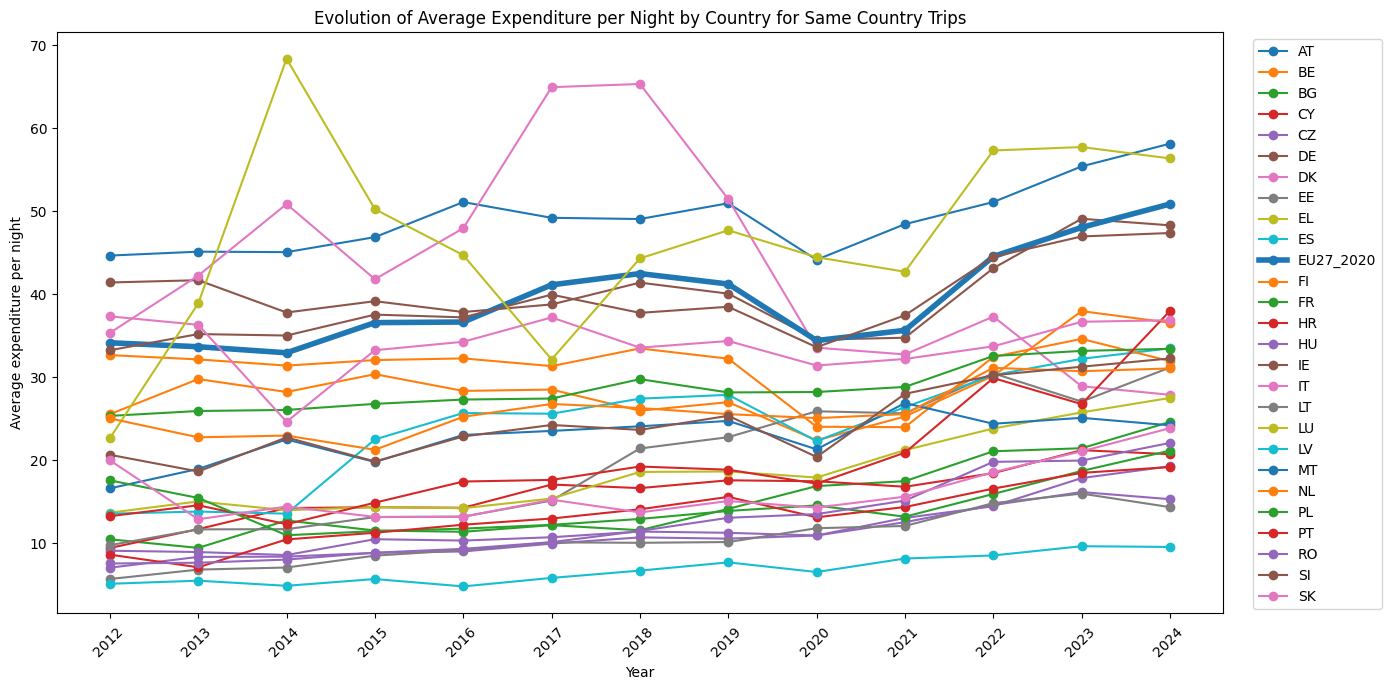

In [9]:
same_country_stats = extotw_cleaned[(extotw_cleaned['geo'] == extotw_cleaned['c_dest']) & (extotw_cleaned['statinfo'] == 'AVG_NGT')].groupby('geo')[years_extotw].mean()


plt.figure(figsize=(14, 7))
highlighted_countries = ['EA20', 'EU27_2020']
for country in same_country_stats.index:
    if country in highlighted_countries:
        plt.plot(
            same_country_stats.columns,
            same_country_stats.loc[country],
            marker="o",
            linewidth=4,
            label=country
        )
    else:
        plt.plot(
            same_country_stats.columns,
            same_country_stats.loc[country],
            alpha=1,
            marker="o",
            label=country
        )
plt.title("Evolution of Average Expenditure per Night by Country for Same Country Trips")
plt.xlabel("Year")  
plt.ylabel("Average expenditure per night")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

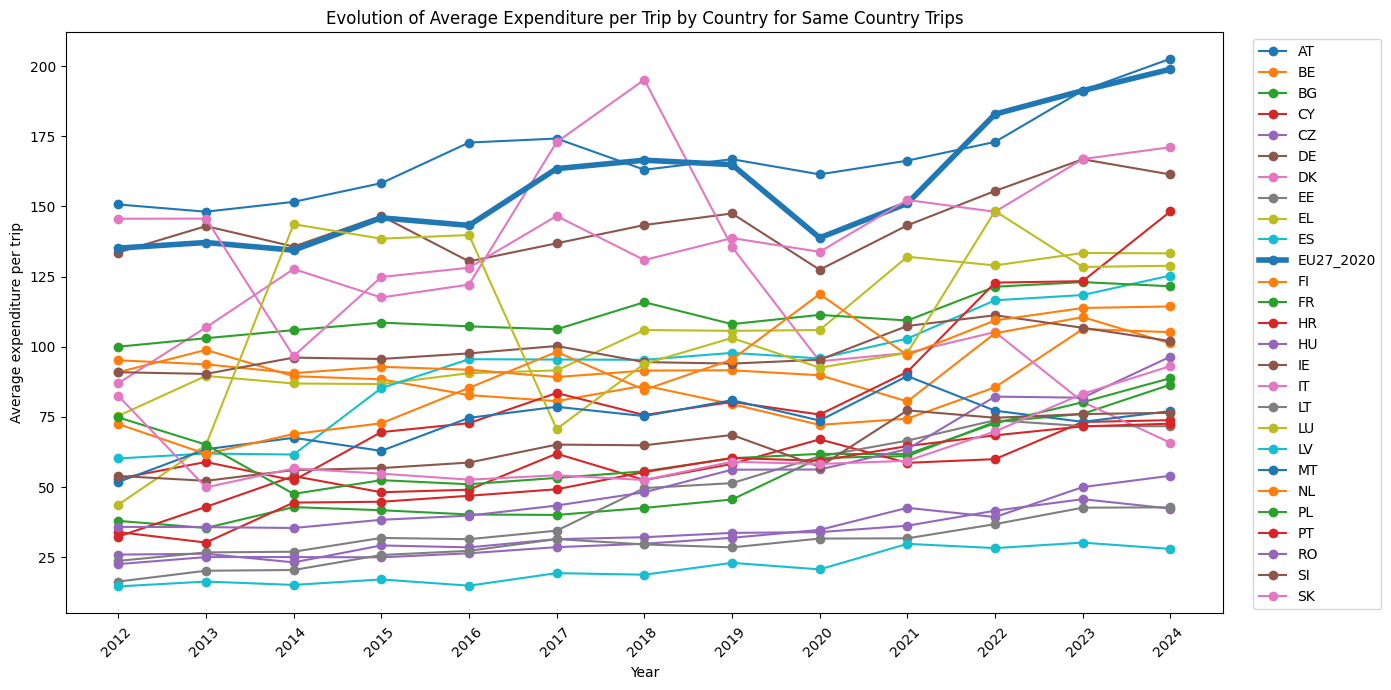

In [10]:
same_country_stats = extotw_cleaned[(extotw_cleaned['geo'] == extotw_cleaned['c_dest']) & (extotw_cleaned['statinfo'] == 'AVG_TRP')].groupby('geo')[years_extotw].mean()


plt.figure(figsize=(14, 7))
highlighted_countries = ['EA20', 'EU27_2020']
for country in same_country_stats.index:
    if country in highlighted_countries:
        plt.plot(
            same_country_stats.columns,
            same_country_stats.loc[country],
            marker="o",
            linewidth=4,
            label=country
        )
    else:
        plt.plot(
            same_country_stats.columns,
            same_country_stats.loc[country],
            alpha=1,
            marker="o",
            label=country
        )
plt.title("Evolution of Average Expenditure per Trip by Country for Same Country Trips")
plt.xlabel("Year")  
plt.ylabel("Average expenditure per trip")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

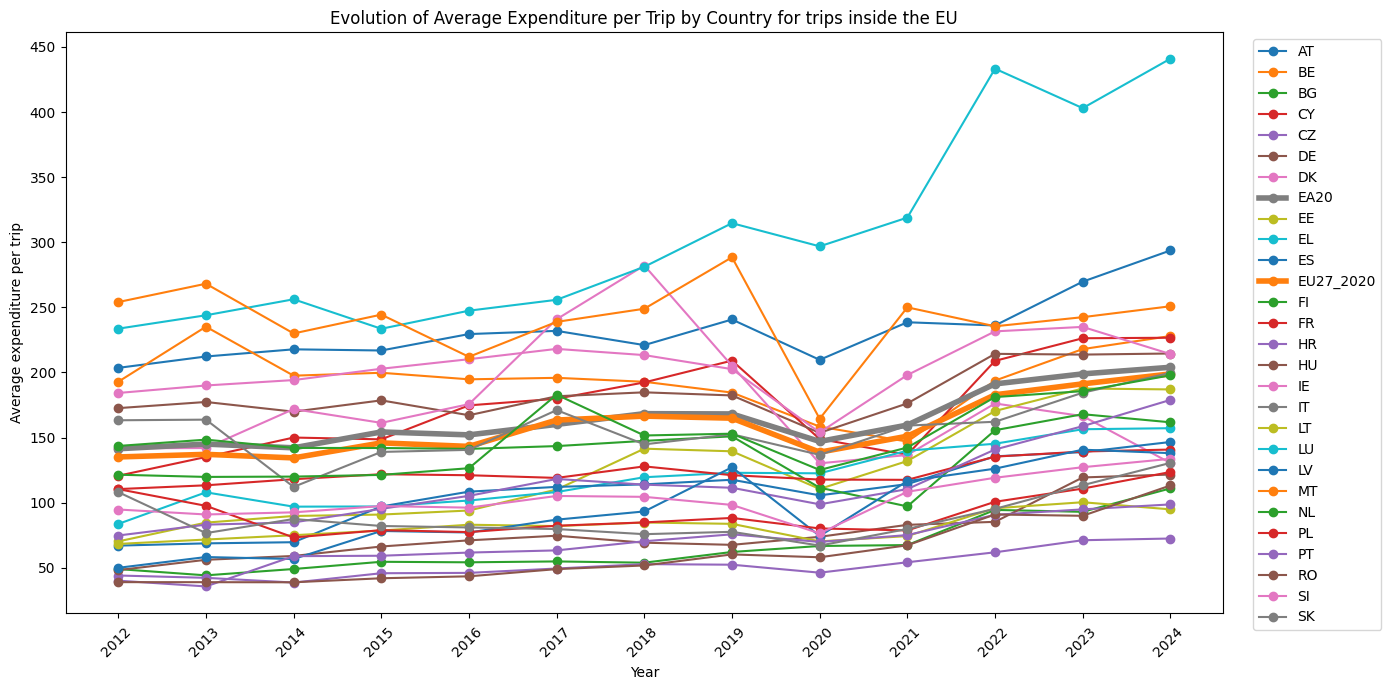

In [11]:
# Average expenditure per trip by country Inside the EU
in_EU_country_stats = extotw_cleaned[('EU27_2020' == extotw_cleaned['c_dest']) & (extotw_cleaned['statinfo'] == 'AVG_TRP')].groupby('geo')[years_extotw].mean()

plt.figure(figsize=(14, 7))
highlighted_countries = ['EA20', 'EU27_2020']
for country in in_EU_country_stats.index:
    if country in highlighted_countries:
        plt.plot(
            in_EU_country_stats.columns,
            in_EU_country_stats.loc[country],
            marker="o",
            linewidth=4,
            label=country
        )
    else:
        plt.plot(
            in_EU_country_stats.columns,
            in_EU_country_stats.loc[country],
            alpha=1,
            marker="o",
            label=country
        )
plt.title("Evolution of Average Expenditure per Trip by Country for trips inside the EU")
plt.xlabel("Year")  
plt.ylabel("Average expenditure per trip")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


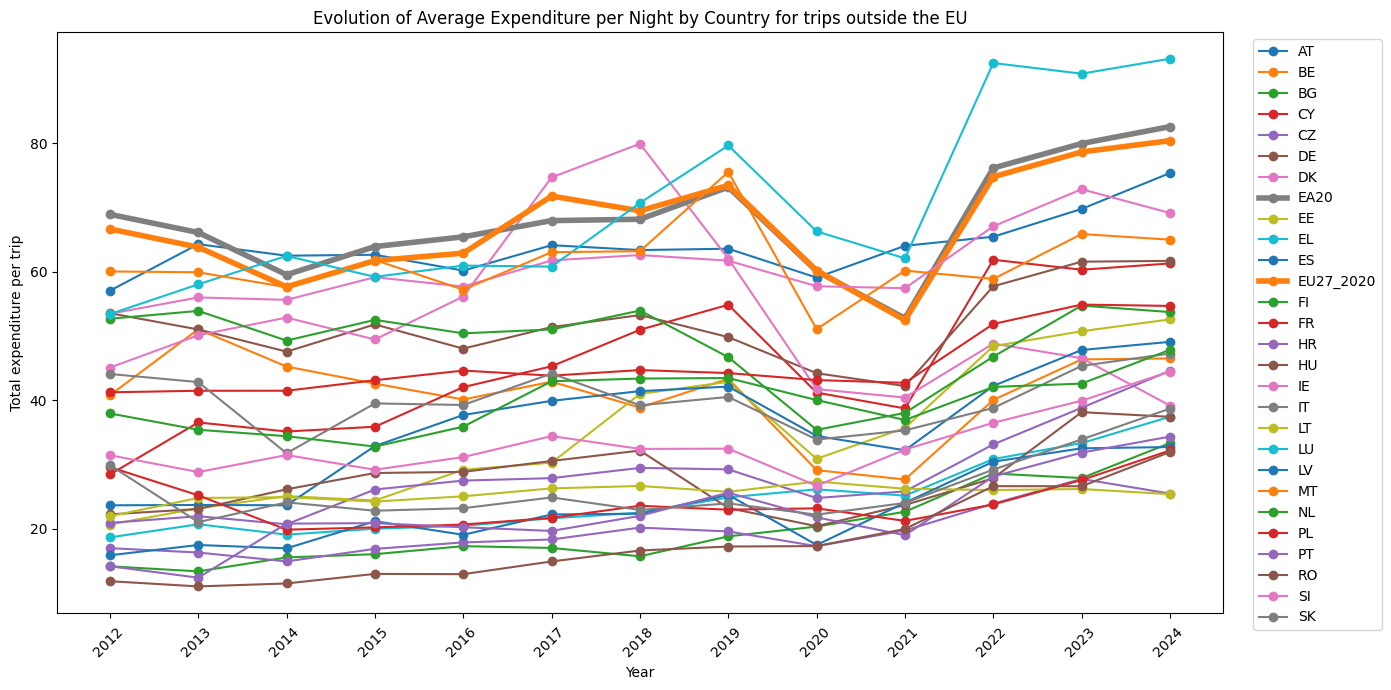

In [12]:
# Total expenditure per trip by country Inside the EU
out_EU_country_stats_avg_ngt = extotw_cleaned[(extotw_cleaned['c_dest'].isin(eu_countries) == False) & (extotw_cleaned['statinfo'] == 'AVG_NGT')].groupby('geo')[years_extotw].mean()

plt.figure(figsize=(14, 7))
highlighted_countries = ['EA20', 'EU27_2020']
for country in out_EU_country_stats_avg_ngt.index:
    if country in highlighted_countries:
        plt.plot(
            out_EU_country_stats_avg_ngt.columns,
            out_EU_country_stats_avg_ngt.loc[country],
            marker="o",
            linewidth=4,
            label=country
        )
    else:
        plt.plot(
            out_EU_country_stats_avg_ngt.columns,
            out_EU_country_stats_avg_ngt.loc[country],
            alpha=1,
            marker="o",
            label=country
        )
plt.title("Evolution of Average Expenditure per Night by Country for trips outside the EU")
plt.xlabel("Year")  
plt.ylabel("Total" \
" expenditure per trip")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

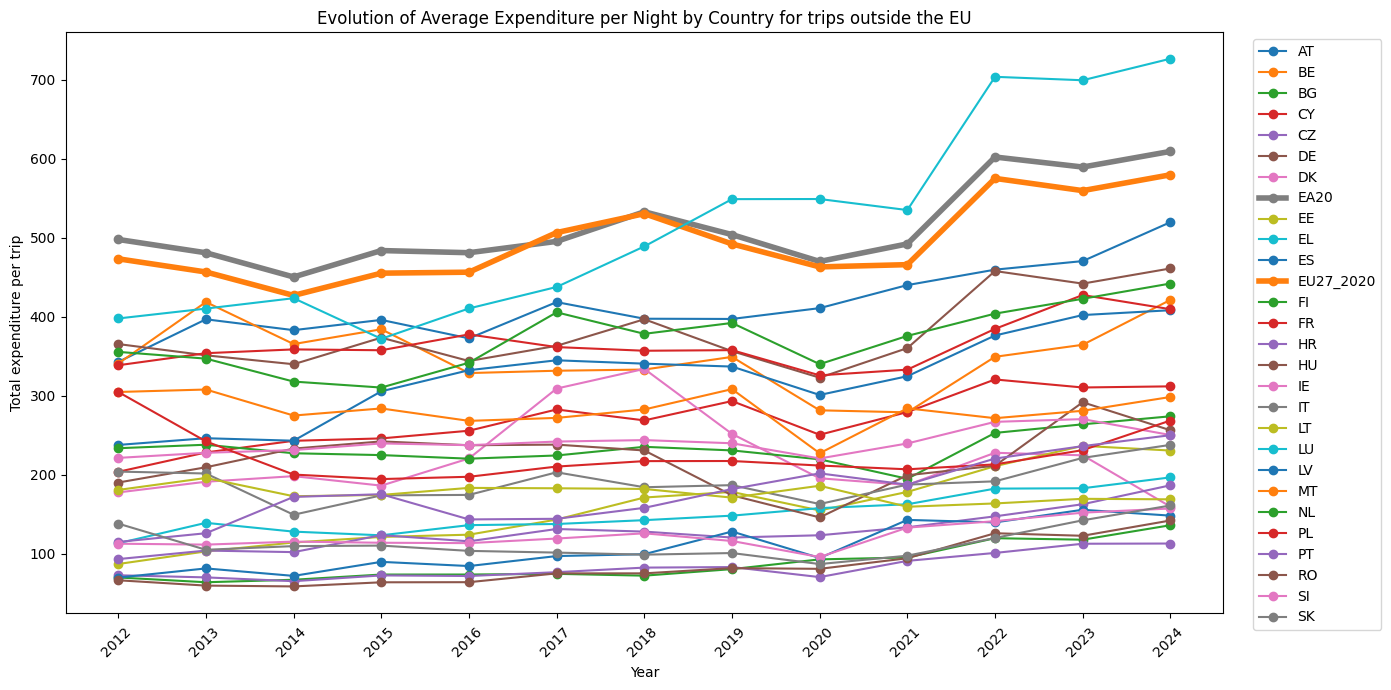

In [13]:
# Total expenditure per trip by country Inside the EU
out_EU_per_trip = extotw_cleaned[(extotw_cleaned['c_dest'].isin(eu_countries) == False) & (extotw_cleaned['statinfo'] == 'AVG_TRP')].groupby('geo')[years_extotw].mean()

plt.figure(figsize=(14, 7))
highlighted_countries = ['EA20', 'EU27_2020']
for country in out_EU_per_trip.index:
    if country in highlighted_countries:
        plt.plot(
            out_EU_per_trip.columns,
            out_EU_per_trip.loc[country],
            marker="o",
            linewidth=4,
            label=country
        )
    else:
        plt.plot(
            out_EU_per_trip.columns,
            out_EU_per_trip.loc[country],
            alpha=1,
            marker="o",
            label=country
        )
plt.title("Evolution of Average Expenditure per Night by Country for trips outside the EU")
plt.xlabel("Year")  
plt.ylabel("Total" \
" expenditure per trip")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

For more visibility

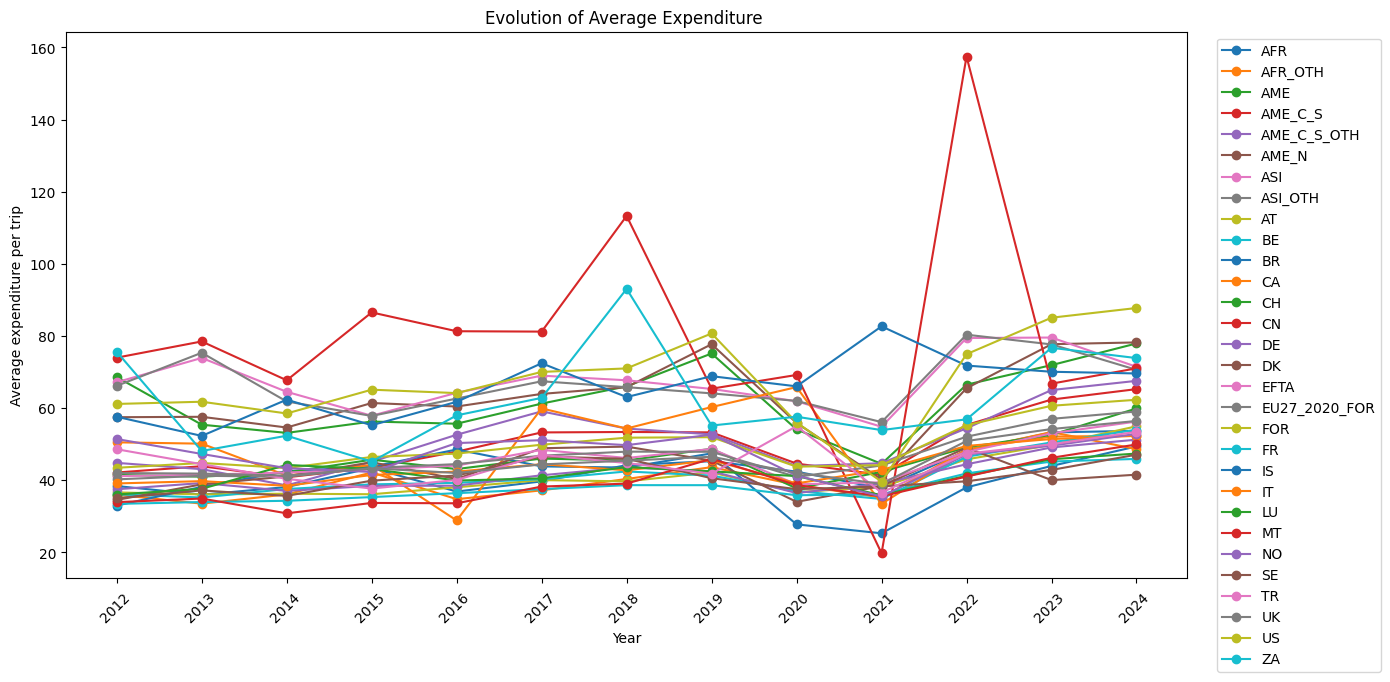

In [14]:
# Average per night expenditure for trips per destination country
avg_expenditure_night_per_dest = extotw_cleaned[extotw_cleaned['statinfo'] == 'AVG_NGT'].groupby('c_dest')[years_extotw].mean()
avg_spending_per_country_trip = avg_expenditure_night_per_dest.groupby('c_dest')[years_extotw].mean()
mean_spending_per_country_trip = avg_spending_per_country_trip[years_extotw].mean(axis=1).sort_values(ascending=False)
top_28_countries = mean_spending_per_country_trip.head(30).index
plt.figure(figsize=(14, 7))
highlighted_countries = []
for country in avg_spending_per_country_trip.index:
    if country in highlighted_countries:
        plt.plot(
            avg_spending_per_country_trip.columns,
            avg_spending_per_country_trip.loc[country],
            marker="o",
            linewidth=4,
            label=country
        )
    elif country in top_28_countries:
        plt.plot(
            avg_spending_per_country_trip.columns,
            avg_spending_per_country_trip.loc[country],
            alpha=1,
            marker="o",
            label=country
        )
plt.title("Evolution of Average Expenditure ")
plt.xlabel("Year")  
plt.ylabel("Average expenditure per trip")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

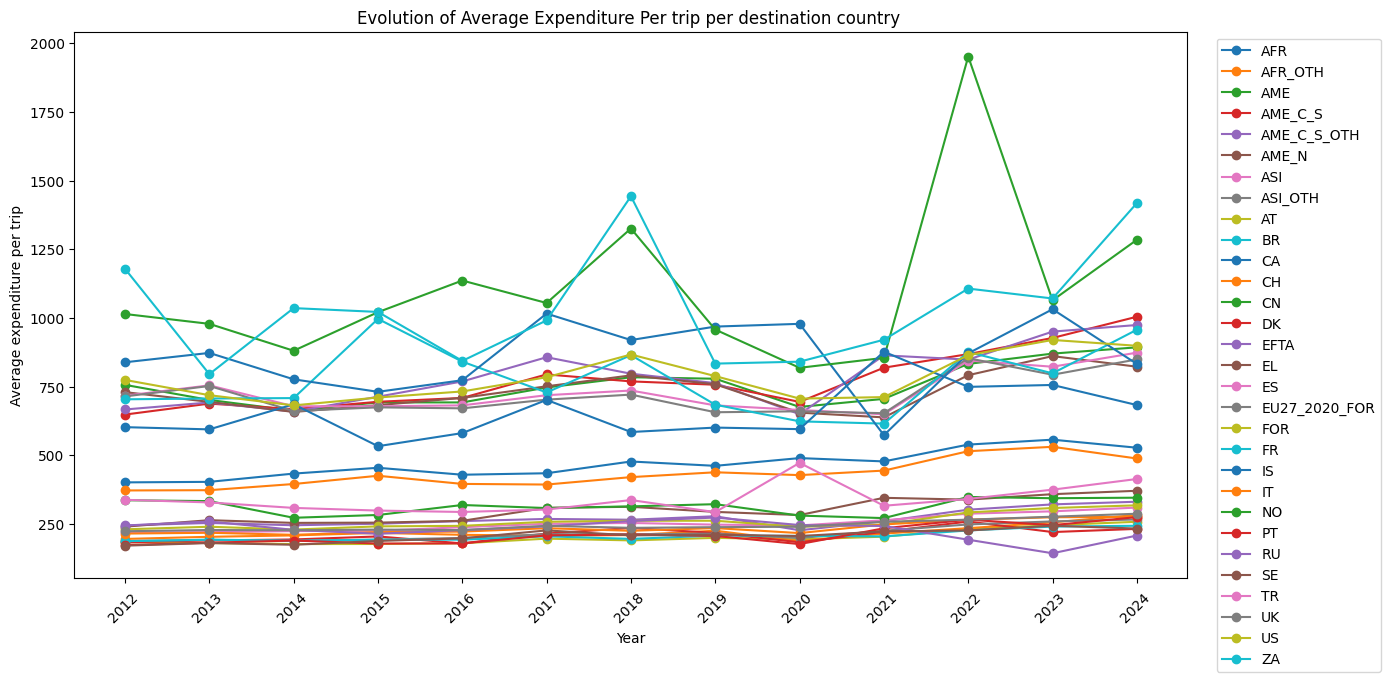

In [15]:
# Average expenditure in the destination country per trip by country
avg_expenditure_trip = extotw_cleaned[extotw_cleaned['statinfo'] == 'AVG_TRP']
avg_spending_per_country_trip = avg_expenditure_trip.groupby('c_dest')[years_extotw].mean()
mean_spending_per_country_trip = avg_spending_per_country_trip[years_extotw].mean(axis=1).sort_values(ascending=False)
top_28_countries = mean_spending_per_country_trip.head(30).index
plt.figure(figsize=(14, 7))
highlighted_countries = []
for country in avg_spending_per_country_trip.index:
    if country in highlighted_countries:
        plt.plot(
            avg_spending_per_country_trip.columns,
            avg_spending_per_country_trip.loc[country],
            marker="o",
            linewidth=4,
            label=country
        )
    elif country in top_28_countries:
        plt.plot(
            avg_spending_per_country_trip.columns,
            avg_spending_per_country_trip.loc[country],
            alpha=1,
            marker="o",
            label=country
        )
plt.title("Evolution of Average Expenditure Per trip per destination country ")
plt.xlabel("Year")  
plt.ylabel("Average expenditure per trip")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Accomodation

### Dataset Description (**tour_dem_tnac**)

We start by explaining the dataset **tour_dem_tnac**, first let's have a look at the cleaned dataset:

In [16]:
tnac_cleaned.head(10)

,c_dest,purpose,duration,accommod,geo,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
7,DOM,PER,N1-3,NR_OTH,DE,2576870.0,3325275.0,1626969.0,1924474.0,3177839.0,3102539.0,3124271.0,7234892.0,3991706.0,3878994.0,5965985.0,6733375.0,2737000.0
9,DOM,PER,N1-3,NR_OTH,EA20,8905441.0,8982985.0,9154112.0,9905183.0,10894972.0,10349096.0,11857565.0,16425436.0,13198663.0,14078784.0,17902428.0,18167261.0,12593475.0
12,DOM,PER,N1-3,NR_OTH,ES,577666.0,456314.0,700749.0,1924327.0,1472399.0,1775132.0,2148269.0,2089094.0,1149003.0,1694209.0,2182001.0,2741779.0,2583717.0
13,DOM,PER,N1-3,NR_OTH,EU27_2020,12423346.0,13643249.0,13020161.0,13894310.0,14901611.0,14387224.0,15149371.0,20986144.0,18780278.0,20315413.0,40565256.0,41865681.0,16118164.0
14,DOM,PER,N1-3,NR_OTH,FI,1009156.0,755254.0,632908.0,759542.0,734714.0,805057.0,1077990.0,1274146.0,871656.0,1064989.0,1228912.0,1026384.0,1081075.0
15,DOM,PER,N1-3,NR_OTH,FR,3032919.0,3353617.0,3661462.0,3125919.0,3057523.0,2666153.0,3448891.0,3939950.0,5434958.0,5519801.0,5348407.0,4228497.0,3579908.0
18,DOM,PER,N1-3,NR_OTH,IE,99714.0,120251.0,94422.0,161009.0,96477.0,107718.0,131681.0,122501.0,287988.0,96132.0,309444.0,185029.0,344935.0
22,DOM,PER,N1-3,NR_OTH,LV,513713.0,145118.0,258930.0,178375.0,189172.0,135846.0,158811.0,62433.0,91458.0,148686.0,97662.0,96868.0,67056.0
28,DOM,PER,N1-3,NR_OTH,PL,1352973.0,1486277.0,451421.0,358606.0,419065.0,580296.0,449932.0,519313.0,432138.0,473537.0,715981.0,608082.0,425633.0
30,DOM,PER,N1-3,NR_OTH,RO,131857.0,931401.0,916138.0,837115.0,865548.0,941486.0,849965.0,787667.0,203119.0,283424.0,306446.0,491158.0,333707.0



This dataset describes the **number of nights spent by tourists according to the main mode of accommodation**, with several dimensions capturing the characteristics of the trip and the traveler.

The variable **`geo`** represents the **country of residence of the tourist**, including individual European countries (e.g., DE, FR, ES) as well as aggregated regions such as **EA20 (Euro Area)** and **EU27_2020 (European Union)**. The variable **`c_dest`** indicates the **destination of the trip**, which is grouped into three categories: **DOM (domestic tourism)**, **FOR (foreign tourism)**, and **WORLD (total tourism)**.

The **`Purpose`** variable specifies the **reason for travel**, distinguishing between **personal trips (PER)** and their subcategories **holidays (PER_HOL)**, **visits to friends and relatives (PER_VFR)**, and **other personal purposes (PER_OTH)** as well as **professional trips (PROF)** and **total trips (TOTAL)**.

The **`Main mode of accommodation`** variable classifies where tourists stay during their trips. It distinguishes between **non-rented accommodation (NR)** such as own properties (NR_OWN), accommodation with relatives or friends (NR_RF), and other non-rented options (NR_OTH), and **rented accommodation (R)** such as hotels (R_HOT), camping sites (R_CAMP), and other rented types (R_OTH). Aggregated categories include **TOT_NR (total non-rented)**, **TOT_R (total rented)**, and **TOTAL (all accommodation types)**.

Finally, the **`Duration`** variable groups trips by the **number of nights spent**, with categories **N1-3 (short trips)**, **N_GE4 (long trips)**, and **N_GE1 (all trips with at least one overnight stay)**. The dataset is structured over multiple years, where each year provides the **number of nights corresponding to each combination of these parameters**, enabling analysis of accommodation preferences and travel behavior over time.

### Data analysis

In [17]:
# Most popular Accomodation overall per year
banned_values =['TOTAL', 'TOT_R', 'TOT_NR']
total_values_by_accomod = tnac_cleaned[tnac_cleaned['accommod'] == 'TOTAL'].groupby('geo')[years_tnac].sum()
accomad_per_year = tnac_cleaned[~tnac_cleaned['accommod'].isin(banned_values)].groupby('accommod')[years_tnac].sum()
percentage_accomad_per_year = accomad_per_year.div(total_values_by_accomod.sum(axis=0), axis=1) * 100
percentage_accomad_per_year

,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
accommod,,,,,,,,,,,,,
NR_OTH,1.600440,1.635387,1.953067,1.820540,1.918580,1.946735,1.838863,2.114337,2.547862,2.430798,3.442096,3.260540,2.356096
NR_OWN,13.073564,13.109455,12.536885,11.476785,11.852222,13.069077,12.973123,13.090658,16.020869,14.090612,11.936685,11.384679,11.853311
NR_RF,32.259831,32.949289,33.046958,33.967506,32.463248,30.853620,29.572330,28.535164,35.475062,34.315351,28.242356,28.597087,27.375887
R_CAMP,5.808622,5.741808,5.749114,6.143742,5.705525,4.872158,5.439404,5.485658,6.012561,6.374232,6.103799,5.322042,5.790491
R_HOT,28.551424,27.681015,27.540677,27.618901,28.564200,29.698383,30.410852,30.727070,18.788609,20.883420,28.470696,29.446792,29.842575
R_OTH,17.032012,17.186958,17.341792,17.191304,17.640230,17.680782,17.799081,17.946718,4.179234,4.147506,4.406652,4.155287,4.247544


In [18]:
# Most popular accomodation type by country
filtered_tnac = tnac_cleaned[~tnac_cleaned['accommod'].isin(banned_values)]
tnac_cleaned_accomod = filtered_tnac.groupby(['geo', 'accommod'])[years_tnac].sum().reset_index()
acc_account = tnac_cleaned_accomod['accommod'].values
id_max_accomod =tnac_cleaned_accomod.groupby('geo')[years_tnac].idxmax().reset_index()
id_max_accomod[years_tnac] = id_max_accomod[years_tnac].apply(lambda x: tnac_cleaned_accomod.loc[x, 'accommod'].values)
id_max_accomod

,geo,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,AT,R_HOT,R_HOT,R_HOT,R_HOT,R_HOT,R_HOT,R_HOT,R_HOT,R_HOT,R_HOT,R_HOT,R_HOT,R_HOT
1,BE,R_HOT,R_HOT,R_HOT,R_HOT,R_HOT,R_HOT,R_HOT,R_HOT,R_HOT,NR_RF,R_HOT,R_HOT,R_HOT
2,BG,NR_RF,NR_RF,R_HOT,NR_RF,NR_RF,R_HOT,R_HOT,R_HOT,R_HOT,R_HOT,R_HOT,R_HOT,R_HOT
3,CY,NR_RF,NR_RF,NR_RF,NR_RF,NR_RF,NR_RF,NR_RF,NR_RF,NR_RF,R_HOT,R_HOT,R_HOT,R_HOT
4,CZ,NR_RF,NR_RF,NR_RF,NR_RF,NR_RF,NR_RF,R_HOT,NR_RF,NR_OWN,NR_OWN,R_HOT,R_HOT,R_HOT
5,DE,R_HOT,R_HOT,R_HOT,R_HOT,R_HOT,R_HOT,R_HOT,R_HOT,NR_RF,R_HOT,R_HOT,R_HOT,R_HOT
6,DK,NR_RF,NR_RF,NR_RF,NR_RF,NR_RF,R_HOT,R_HOT,R_HOT,NR_RF,NR_RF,R_HOT,R_HOT,R_HOT
7,EA20,NR_RF,NR_RF,NR_RF,NR_RF,NR_RF,NR_RF,R_HOT,R_HOT,NR_RF,NR_RF,R_HOT,R_HOT,R_HOT
8,EE,NR_RF,NR_RF,NR_RF,NR_RF,NR_RF,R_HOT,R_HOT,R_HOT,R_HOT,R_HOT,R_HOT,R_HOT,R_HOT
9,EL,NR_OWN,NR_RF,NR_RF,NR_OWN,NR_OWN,NR_OWN,NR_OWN,NR_OWN,NR_OWN,NR_OWN,NR_OWN,NR_OWN,NR_OWN


In [19]:
# Per destination country, the most popular accomodation type
dest_tnac_cleaned_accomod = filtered_tnac.groupby(['c_dest', 'accommod'])[years_tnac].sum().reset_index()
dest_acc_account = dest_tnac_cleaned_accomod['accommod'].values
dest_id_max_accomod =dest_tnac_cleaned_accomod.groupby('c_dest')[years_tnac].idxmax().reset_index()
dest_id_max_accomod[years_tnac] = dest_id_max_accomod[years_tnac].apply(lambda x: dest_tnac_cleaned_accomod.loc[x, 'accommod'].values)
dest_id_max_accomod


,c_dest,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,DOM,NR_RF,NR_RF,NR_RF,NR_RF,NR_RF,NR_RF,NR_RF,NR_RF,NR_RF,NR_RF,NR_RF,NR_RF,NR_RF
1,FOR,R_HOT,R_HOT,R_HOT,R_HOT,R_HOT,R_HOT,R_HOT,R_HOT,R_HOT,R_HOT,R_HOT,R_HOT,R_HOT
2,WORLD,NR_RF,NR_RF,NR_RF,NR_RF,NR_RF,NR_RF,R_HOT,R_HOT,NR_RF,NR_RF,R_HOT,R_HOT,R_HOT


## Transportation

### Dataset Description (**tour_dem_tttr**)

We start by explaining the dataset **tour_dem_tttr**, first let's have a look at the cleaned dataset:

In [24]:
tttr_cleaned.head(10)

,c_dest,purpose,duration,tra_mode,geo,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
7,DOM,PER,N1-3,AIR,EA20,5572547.0,4756878.0,4294158.0,4433821.0,5475152.0,6336875.0,6226517.0,6578726.0,3451957.0,3771839.0,6512168.0,6580682.0,5534339.0
9,DOM,PER,N1-3,AIR,EL,86542.0,27720.0,48961.0,69427.0,50980.0,63863.0,68320.0,53478.0,30313.0,38778.0,80183.0,70500.0,79179.0
10,DOM,PER,N1-3,AIR,ES,1622357.0,1406057.0,1318213.0,1496731.0,1840164.0,1968842.0,2459277.0,2517957.0,837043.0,1475916.0,2274329.0,3060881.0,3045632.0
11,DOM,PER,N1-3,AIR,EU27_2020,6616407.0,5695687.0,5073105.0,5321886.0,6430422.0,7279047.0,7000301.0,7527384.0,3710272.0,4231546.0,7292537.0,7349717.0,6125285.0
13,DOM,PER,N1-3,AIR,FR,1088151.0,1020170.0,936314.0,1049924.0,929916.0,1336385.0,1247478.0,1380651.0,1782294.0,1443965.0,2394343.0,1891712.0,1143370.0
17,DOM,PER,N1-3,AIR,IT,972454.0,671144.0,638631.0,725754.0,653282.0,1384263.0,1100775.0,1075311.0,349968.0,389982.0,1034710.0,776962.0,650059.0
23,DOM,PER,N1-3,AIR,PT,32753.0,50871.0,45548.0,73259.0,96405.0,161347.0,140265.0,126309.0,52916.0,78682.0,144201.0,167458.0,186266.0
31,DOM,PER,N1-3,BUS,AT,267038.0,242279.0,250460.0,283850.0,351362.0,316326.0,342106.0,316449.0,103381.0,126339.0,306316.0,286486.0,280344.0
33,DOM,PER,N1-3,BUS,BG,477511.0,350654.0,339762.0,229616.0,299223.0,391768.0,340792.0,338681.0,117212.0,170299.0,185836.0,208253.0,223184.0
36,DOM,PER,N1-3,BUS,CZ,1718189.0,1796211.0,1261758.0,1391137.0,1086389.0,1330462.0,998446.0,957847.0,557232.0,744439.0,880265.0,550073.0,744246.0


This dataset describes the **number of trips made by tourists according to the main mode of transport**, providing insights into how people travel based on destination, purpose, and trip characteristics.

The variable **`geo`** represents the **country of residence of the tourist**, including individual European countries (e.g., FR, IT, DE, ES) as well as aggregated regions such as **EA20 (Euro Area)** and **EU27_2020 (European Union)**. The variable **`c_dest`** indicates the **destination of the trip**, grouped into **DOM (domestic trips)**, **FOR (foreign trips)**, and **WORLD (total trips)**.

The **`tra_mode`** variable specifies the **main mode of transport used during the trip**. It includes **AIR (air transport)**, **RAIL (train)**, **BUS (bus/coach)**, and road-based categories such as **RDMV_PAS_X_BUS (road motor vehicles excluding buses, e.g., cars)** and **LAND (total land transport)** with **LAND_OTH (other land transport)**. Additional aggregated categories include **TOTAL (all transport modes)** and **WW (waterways)**.

The **`duration`** variable classifies trips by their **length in nights**, with **N1-3 (short trips)**, **N_GE4 (long trips)**, and **N_GE1 (all trips with at least one overnight stay)**.

The dataset is organized over multiple years, where each year provides the **number of trips corresponding to each combination of country of residence, destination, transport mode, and duration**, allowing for analysis of travel behavior and transport preferences over time.

### Data analysis

In [49]:
# Most popular of transportation type by country
banned_transport_values = ['TOTAL', 'LAND']
geo_transport = tttr_cleaned[~tttr_cleaned['tra_mode'].isin(banned_transport_values)].groupby(['geo', 'tra_mode'])[years_tttr].sum().reset_index()
transport_account = geo_transport['tra_mode'].values
id_max_transport = geo_transport.groupby('geo')[years_tttr].idxmax().reset_index()
id_max_transport[years_tttr] = id_max_transport[years_tttr].apply(lambda x: geo_transport.loc[x, 'tra_mode'].values)
id_max_transport

,geo,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,AT,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS
1,BE,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS
2,BG,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS
3,CY,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,AIR,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,AIR,AIR
4,CZ,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS
5,DE,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS
6,DK,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS
7,EA20,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS
8,EE,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS
9,EL,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS


In [50]:
# Most popular per desdtination
dest_transport = tttr_cleaned[~tttr_cleaned['tra_mode'].isin(banned_transport_values)].groupby(['c_dest', 'tra_mode'])[years_tttr].sum().reset_index()
dest_id_max_transport = dest_transport.groupby('c_dest')[years_tttr].idxmax().reset_index()
dest_id_max_transport[years_tttr] = dest_id_max_transport[years_tttr].apply(lambda x: dest_transport.loc[x, 'tra_mode'].values)
dest_id_max_transport

,c_dest,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,DOM,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS
1,FOR,AIR,AIR,AIR,AIR,AIR,AIR,AIR,AIR,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,AIR,AIR,AIR
2,WORLD,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS


In [51]:
# Msost popular per purpose
purpose_transport = tttr_cleaned[~tttr_cleaned['tra_mode'].isin(banned_transport_values)].groupby(['purpose', 'tra_mode'])[years_tttr].sum().reset_index()
purpose_id_max_transport = purpose_transport.groupby('purpose')[years_tttr].idxmax().reset_index()
purpose_id_max_transport[years_tttr] = purpose_id_max_transport[years_tttr].apply(lambda x: purpose_transport.loc[x, 'tra_mode'].values)
purpose_id_max_transport

,purpose,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,PER,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS
1,PROF,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS
2,TOTAL,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS


In [52]:
# Most popular per duration
duration_transport = tttr_cleaned[~tttr_cleaned['tra_mode'].isin(banned_transport_values)].groupby(['duration', 'tra_mode'])[years_tttr].sum().reset_index()
duration_id_max_transport = duration_transport.groupby('duration')[years_tttr].idxmax().reset_index()
duration_id_max_transport[years_tttr] = duration_id_max_transport[years_tttr].apply(lambda x: duration_transport.loc[x, 'tra_mode'].values)
duration_id_max_transport

,duration,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,N1-3,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS
1,N_GE1,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS
2,N_GE4,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS,RDMV_PAS_X_BUS


## Nights Spent

### Dataset Description (**tour_dem_tnw**)

### Data analysis

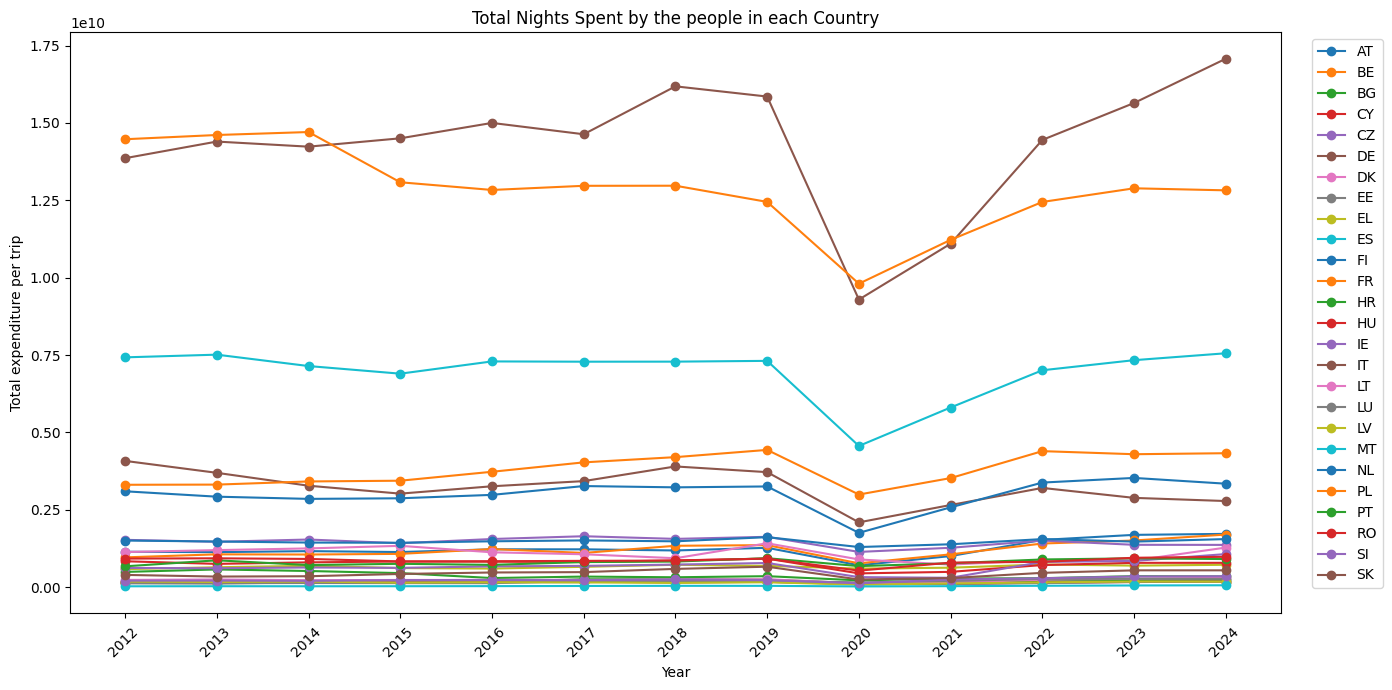

In [28]:
# All nights spent
all_nights_spent = tnw_cleaned[tnw_cleaned['duration'] == 'N_GE1']
geo_night_spent = all_nights_spent.groupby('geo')[years_tnw].sum()

plt.figure(figsize=(14, 7))
highlighted_countries = ['EA20', 'EU27_2020']
for country in geo_night_spent.index:
    if country in highlighted_countries:
        continue
    else:
        plt.plot(
            geo_night_spent.columns,
            geo_night_spent.loc[country],
            alpha=1,
            marker="o",
            label=country
        )
plt.title("Total Nights Spent by the people in each Country")
plt.xlabel("Year")  
plt.ylabel("Total" \
" expenditure per trip")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

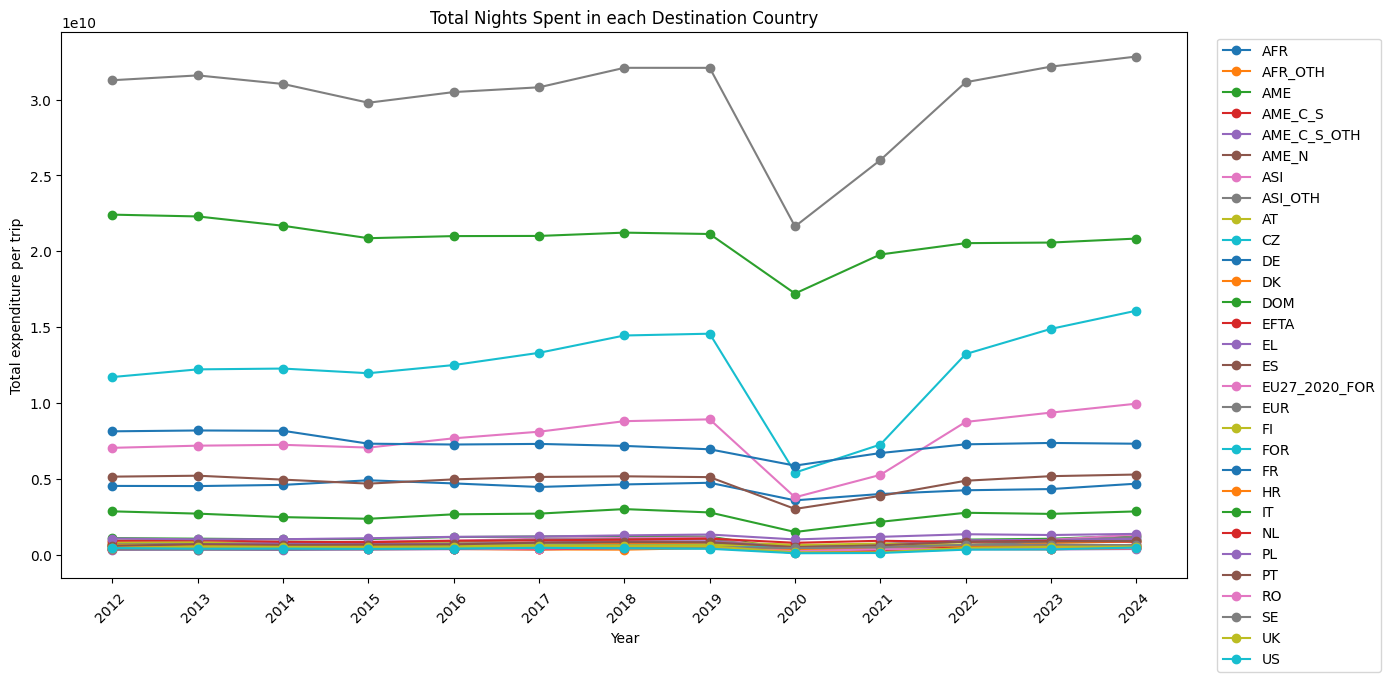

In [ ]:
# Total nights spent per destination country
dest_night_spent = all_nights_spent.groupby('c_dest')[years_tnw].sum()
mean_dest_night_spent = dest_night_spent[years_tnw].mean(axis=1).sort_values(ascending=False)
top_destinations = mean_dest_night_spent.head(32).index
plt.figure(figsize=(14, 7))
highlighted_countries = ['EA20', 'EU27_2020', 'WORLD', 'EU27_2020', 'EU28', 'EU27_2019', 'AFR', 'AFR_OTH', 'AME', 'AME_C_S', 'AME_C_S_OTH', 'AME_N', 'ASI', 'ASI_OTH']
for country in dest_night_spent.index:
    if country in highlighted_countries:
        continue
    elif country in top_destinations:
        plt.plot(
            dest_night_spent.columns,
            dest_night_spent.loc[country],
            alpha=1,
            marker="o",
            label=country
        )
plt.title("Total Nights Spent in each Destination Country")
plt.xlabel("Year")  
plt.ylabel("Total" \
" expenditure per trip")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [60]:
# Ppopular time per country per year
night_banned_values = ['N_GE1']
geo_pop_night = tnw_cleaned[~tnw_cleaned['duration'].isin(night_banned_values)].groupby(['geo', 'duration'])[years_tnw].sum().reset_index()
night_account = geo_pop_night['duration'].values
id_max_night = geo_pop_night.groupby('geo')[years_tnw].idxmax().reset_index()
id_max_night[years_tnw] = id_max_night[years_tnw].apply(lambda x: geo_pop_night.loc[x, 'duration'].values)
id_max_night

,geo,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,AT,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4
1,BE,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4
2,BG,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4
3,CY,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4
4,CZ,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4
5,DE,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4
6,DK,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4
7,EA20,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4
8,EE,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4
9,EL,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4


In [61]:
# Night spent per destination$
dest_night_pop = tnw_cleaned[~tnw_cleaned['duration'].isin(night_banned_values)].groupby(['c_dest', 'duration'])[years_tnw].sum().reset_index()
dest_id_max_night = dest_night_pop.groupby('c_dest')[years_tnw].idxmax().reset_index()
dest_id_max_night[years_tnw] = dest_id_max_night[years_tnw].apply(lambda x: dest_night_pop.loc[x, 'duration'].values)
dest_id_max_night

,c_dest,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,AFR,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4
1,AFR_OTH,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4
2,AME,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4
3,AME_C_S,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4
4,AME_C_S_OTH,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4
5,AME_N,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4
6,ASI,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4
7,ASI_OTH,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4
8,AT,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4
9,BE,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4


In [62]:
# Night per purpose
purpose_night_pop = tnw_cleaned[~tnw_cleaned['duration'].isin(night_banned_values)].groupby(['purpose', 'duration'])[years_tnw].sum().reset_index()
purpose_id_max_night = purpose_night_pop.groupby('purpose')[years_tnw].idxmax().reset_index()
purpose_id_max_night[years_tnw] = purpose_id_max_night[years_tnw].apply(lambda x: purpose_night_pop.loc[x, 'duration'].values)
purpose_id_max_night

,purpose,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,PER,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4
1,PER_VFR,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4
2,PROF,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4
3,TOTAL,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4


In [63]:
# Night spent in the EU from the EU
in_EU_nights = tnw_cleaned[(tnw_cleaned['c_dest'].isin(eu_countries)) & (tnw_cleaned['duration'] != 'N_GE1')].groupby(['geo', 'duration'])[years_tnw].sum().reset_index()
in_EU_id_max_night = in_EU_nights.groupby('geo')[years_tnw].idxmax().reset_index()
in_EU_id_max_night[years_tnw] = in_EU_id_max_night[years_tnw].apply(lambda x: in_EU_nights.loc[x, 'duration'].values)
in_EU_id_max_night

,geo,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,AT,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4
1,BE,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4
2,BG,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4
3,CY,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4
4,CZ,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4
5,DE,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4
6,DK,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4
7,EA20,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4
8,EE,N_GE4,N1-3,N1-3,N1-3,N1-3,N1-3,N1-3,N1-3,N1-3,N1-3,N1-3,N1-3,N1-3
9,EL,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4,N_GE4


## Origin of Tourists

In [68]:
arnraw_cleaned

,freq,unit,c_resid,nace_r2,geo,1990,1991,1992,1993,1994,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
1,A,NR,AFR,I551,AT,19128.0,17603.0,22445.0,22713.0,21114.0,...,64735.0,68031.0,66466.0,69141.0,67764.0,16609.0,13859.0,47110.0,61591.0,64086.0
7,A,NR,AFR,I551,DE,164527.0,127807.0,132342.0,119588.0,105066.0,...,252381.0,240027.0,248202.0,249477.0,260656.0,66919.0,56454.0,178585.0,211797.0,228564.0
20,A,NR,AFR,I551,FR,519123.0,479083.0,371588.0,320060.0,349928.0,...,675086.0,694087.0,749974.0,789038.0,719352.0,185032.0,240290.0,574183.0,637151.0,644727.0
33,A,NR,AFR,I551,NL,47100.0,44900.0,42700.0,41900.0,42000.0,...,127241.0,134765.0,149034.0,150967.0,182477.0,47454.0,44103.0,130655.0,151805.0,169986.0
36,A,NR,AFR,I551,PT,58117.0,54521.0,52014.0,53285.0,44231.0,...,142967.0,143545.0,164667.0,164138.0,173179.0,45040.0,55082.0,143687.0,174968.0,194869.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13233,A,NR,WORLD,I552_I553,BG,1467412.0,525761.0,486178.0,376688.0,382267.0,...,535437.0,604453.0,628901.0,674796.0,712244.0,471082.0,560804.0,678980.0,773284.0,785664.0
13271,A,NR,WORLD,I552_I553,SK,1078572.0,656824.0,415566.0,352213.0,513574.0,...,894965.0,1030108.0,1098335.0,1165819.0,1377847.0,765342.0,630490.0,934408.0,1181560.0,1222312.0
13319,A,NR,WRL_NAL,I551,AT,297200.0,336848.0,306251.0,288089.0,314798.0,...,244288.0,283585.0,278598.0,261022.0,292979.0,140288.0,127762.0,244262.0,325675.0,408614.0
13325,A,NR,WRL_NAL,I551,DE,221537.0,251008.0,339054.0,334991.0,375446.0,...,746719.0,767450.0,776962.0,889067.0,739976.0,241748.0,173542.0,380014.0,562536.0,707698.0


In [71]:
# Most popular country of origin per destination
banned_values_residence = ['WORLD']
filtered_arnraw = arnraw_cleaned[~arnraw_cleaned['c_resid'].isin(banned_values_residence)]
c_resid_arnraw_geo = filtered_arnraw.groupby(['geo', 'c_resid'])[years_arnraw].sum().reset_index()
c_resid_arnraw_geo_account = c_resid_arnraw_geo['c_resid'].values
c_resid_arnraw_geo_id_max = c_resid_arnraw_geo.groupby('geo')[years_arnraw].idxmax().reset_index()
c_resid_arnraw_geo_id_max[years_arnraw] = c_resid_arnraw_geo_id_max[years_arnraw].apply(lambda x: c_resid_arnraw_geo.loc[x, 'c_resid'].values)
c_resid_arnraw_geo_id_max

,geo,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,AT,DE,DE,DE,DE,DE,DE,DE,DE,DE,...,AT,AT,AT,AT,AT,AT,AT,AT,AT,AT
1,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,...,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG
2,DE,DE,DE,DE,DE,DE,DE,DE,DE,DE,...,DE,DE,DE,DE,DE,DE,DE,DE,DE,DE
3,ES,ES,ES,ES,ES,ES,ES,ES,ES,ES,...,ES,ES,ES,ES,ES,ES,ES,ES,ES,ES
4,FR,DE,DE,DE,DE,DE,DE,DE,DE,DE,...,DE,DE,DE,DE,DE,BE,DE,DE,DE,DE
5,IT,IT,IT,IT,IT,IT,IT,IT,IT,IT,...,IT,IT,IT,IT,IT,IT,IT,IT,IT,IT
6,LU,BE,BE,BE,BE,BE,BE,BE,BE,BE,...,LU,LU,LU,LU,LU,LU,LU,LU,LU,LU
7,NL,NL,NL,NL,NL,NL,NL,NL,NL,NL,...,NL,NL,NL,NL,NL,NL,NL,NL,NL,NL
8,PT,PT,PT,PT,PT,PT,PT,PT,PT,PT,...,PT,PT,PT,PT,PT,PT,PT,PT,PT,PT
9,SE,SE,SE,SE,SE,SE,SE,SE,SE,SE,...,SE,SE,SE,SE,SE,SE,SE,SE,SE,SE


In [73]:
# Most popular country of origin per destination except same couutry
filtered_arnraw_same = arnraw_cleaned[(arnraw_cleaned['c_resid'] != arnraw_cleaned['geo']) & (arnraw_cleaned['c_resid'] != 'WORLD')]
filtered_arnraw_same = filtered_arnraw_same[~filtered_arnraw_same['c_resid'].isin(banned_values)]
c_resid_arnraw_geo_same = filtered_arnraw_same.groupby(['geo', 'c_resid'])[years_arnraw].sum().reset_index()
c_resid_arnraw_geo_same_account = c_resid_arnraw_geo_same['c_resid'].values
c_resid_arnraw_geo_same_id_max = c_resid_arnraw_geo_same.groupby('geo')[years_arnraw].idxmax().reset_index()
c_resid_arnraw_geo_same_id_max[years_arnraw] = c_resid_arnraw_geo_same_id_max[years_arnraw].apply(lambda x: c_resid_arnraw_geo_same.loc[x, 'c_resid'].values)
c_resid_arnraw_geo_same_id_max

,geo,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,AT,DE,DE,DE,DE,DE,DE,DE,DE,DE,...,DE,DE,DE,DE,DE,DE,DE,DE,DE,DE
1,DE,AME,NL,NL,NL,NL,NL,NL,NL,AME,...,ASI,NL,ASI,ASI,NL,NL,NL,NL,NL,NL
2,ES,DE,DE,DE,DE,DE,DE,DE,DE,DE,...,UK,UK,UK,UK,UK,UK,FR,UK,UK,UK
3,FR,DE,DE,DE,DE,DE,DE,DE,DE,DE,...,DE,DE,DE,DE,DE,BE,DE,DE,DE,DE
4,IT,DE,DE,DE,DE,DE,DE,DE,DE,DE,...,DE,DE,DE,DE,DE,DE,DE,DE,DE,DE
5,LU,BE,BE,BE,BE,BE,BE,BE,BE,BE,...,BE,BE,BE,BE,BE,BE,BE,BE,BE,BE
6,NL,DE,DE,DE,DE,DE,DE,DE,DE,DE,...,DE,DE,DE,DE,DE,DE,DE,DE,DE,DE
7,PT,ES,ES,ES,ES,DE,DE,DE,DE,ES,...,ES,ES,AME,AME,AME,ES,ES,AME,AME,AME


In [77]:
# Favorite stay per country of residence
banned_values_stay = ['I551-I553', 'I552_I553']
filtered_arnraw_stay = arnraw_cleaned[~arnraw_cleaned['nace_r2'].isin(banned_values_stay)]
c_resid_arnraw_stay = filtered_arnraw_stay.groupby(['c_resid', 'nace_r2'])[years_arnraw].sum().reset_index()
c_resid_arnraw_stay_account = c_resid_arnraw_stay['nace_r2'].values
c_resid_arnraw_stay_id_max = c_resid_arnraw_stay.groupby('c_resid')[years_arnraw].idxmax().reset_index()
c_resid_arnraw_stay_id_max[years_arnraw] = c_resid_arnraw_stay_id_max[years_arnraw].apply(lambda x: c_resid_arnraw_stay.loc[x, 'nace_r2'].values)
c_resid_arnraw_stay_id_max



,c_resid,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,AFR,I551,I551,I551,I551,I551,I551,I551,I551,I551,...,I551,I551,I551,I551,I551,I551,I551,I551,I551,I551
1,AME,I551,I551,I551,I551,I551,I551,I551,I551,I551,...,I551,I551,I551,I551,I551,I551,I551,I551,I551,I551
2,AME_C_S,I551,I551,I551,I551,I551,I551,I551,I551,I551,...,I551,I551,I551,I551,I551,I551,I551,I551,I551,I551
3,AME_N,I551,I551,I551,I551,I551,I551,I551,I551,I551,...,I551,I551,I551,I551,I551,I551,I551,I551,I551,I551
4,ASI,I551,I551,I551,I551,I551,I551,I551,I551,I551,...,I551,I551,I551,I551,I551,I551,I551,I551,I551,I551
5,AT,I551,I551,I551,I551,I551,I551,I551,I551,I551,...,I551,I551,I551,I551,I551,I551,I551,I551,I551,I551
6,AU,I551,I551,I551,I551,I551,I551,I551,I551,I551,...,I551,I551,I551,I551,I551,I551,I551,I551,I551,I551
7,BE,I551,I551,I551,I551,I551,I551,I551,I551,I551,...,I551,I551,I551,I551,I551,I551,I551,I551,I551,I551
8,BG,I551,I551,I551,I551,I551,I551,I551,I551,I551,...,I551,I551,I551,I551,I551,I551,I551,I551,I551,I551
9,CA,I551,I551,I551,I551,I551,I551,I551,I551,I551,...,I551,I551,I551,I551,I551,I551,I551,I551,I551,I551


In [78]:
# Favorite stay in geo
c_resid_arnraw_stay_geo = filtered_arnraw_stay.groupby(['geo', 'nace_r2'])[years_arnraw].sum().reset_index()
c_resid_arnraw_stay_geo_account = c_resid_arnraw_stay_geo['nace_r2'].values
c_resid_arnraw_stay_geo_id_max = c_resid_arnraw_stay_geo.groupby('geo')[years_arnraw].idxmax().reset_index()
c_resid_arnraw_stay_geo_id_max[years_arnraw] = c_resid_arnraw_stay_geo_id_max[years_arnraw].apply(lambda x: c_resid_arnraw_stay_geo.loc[x, 'nace_r2'].values)
c_resid_arnraw_stay_geo_id_max

,geo,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,AT,I551,I551,I551,I551,I551,I551,I551,I551,I551,...,I551,I551,I551,I551,I551,I551,I551,I551,I551,I551
1,BG,I551,I551,I551,I551,I551,I551,I551,I551,I551,...,I551,I551,I551,I551,I551,I551,I551,I551,I551,I551
2,DE,I551,I551,I551,I551,I551,I551,I551,I551,I551,...,I551,I551,I551,I551,I551,I551,I551,I551,I551,I551
3,ES,I551,I551,I551,I551,I551,I551,I551,I551,I551,...,I551,I551,I551,I551,I551,I551,I551,I551,I551,I551
4,FR,I551,I551,I551,I551,I551,I551,I551,I551,I551,...,I551,I551,I551,I551,I551,I551,I551,I551,I551,I551
5,IT,I551,I551,I551,I551,I551,I551,I551,I551,I551,...,I551,I551,I551,I551,I551,I551,I551,I551,I551,I551
6,LU,I551,I551,I551,I551,I551,I551,I551,I551,I551,...,I551,I551,I551,I551,I551,I551,I551,I551,I551,I551
7,NL,I551,I551,I551,I551,I551,I551,I551,I551,I551,...,I551,I551,I551,I551,I551,I551,I551,I551,I551,I551
8,PT,I551,I551,I551,I551,I551,I551,I551,I551,I551,...,I551,I551,I551,I551,I551,I551,I551,I551,I551,I551
9,SE,I551,I551,I551,I551,I551,I551,I551,I551,I551,...,I551,I551,I551,I551,I551,I551,I551,I551,I551,I551


## Status of activity of each tourist.

### Dataset Description 

In [25]:
ttws_cleaned.head(10)

,c_dest,purpose,duration,wstatus,geo,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
1,DOM,PER,N1-3,ACT_INAC,AT,5777112.0,6314809.0,6709183.0,6351613.0,6882323.0,6764655.0,7361385.0,7909105.0,6288046.0,6677951.0,9499556.0,9211332.0,9369123.0
2,DOM,PER,N1-3,ACT_INAC,BE,1489881.0,1670786.0,1435782.0,2235671.0,1698476.0,2175530.0,2469676.0,2782431.0,2219809.0,3606225.0,3316240.0,3403263.0,3115789.0
3,DOM,PER,N1-3,ACT_INAC,BG,1941286.0,1877711.0,1855864.0,1424295.0,1596173.0,2736847.0,2335183.0,2204807.0,1208155.0,1677700.0,1967127.0,2030006.0,2265996.0
5,DOM,PER,N1-3,ACT_INAC,CY,1074564.0,879804.0,962785.0,1082593.0,1114113.0,1167110.0,1329479.0,1365000.0,1444892.0,1586491.0,1349181.0,1251908.0,1282637.0
6,DOM,PER,N1-3,ACT_INAC,CZ,18628902.0,17215083.0,18528217.0,16203332.0,17702092.0,20061639.0,18498367.0,18301424.0,12774637.0,14492600.0,17453952.0,12840828.0,14488088.0
7,DOM,PER,N1-3,ACT_INAC,DE,84908064.0,87350273.0,80109555.0,89534444.0,87104335.0,79063521.0,82390597.0,84381050.0,57445754.0,70272824.0,67283380.0,78472262.0,84913829.0
8,DOM,PER,N1-3,ACT_INAC,DK,17342909.0,19196406.0,19511192.0,19496387.0,17400216.0,13838114.0,6588550.0,12339753.0,11990566.0,8744466.0,8456216.0,7935700.0,11015358.0
9,DOM,PER,N1-3,ACT_INAC,EE,1353968.0,1386473.0,2048022.0,2147737.0,2598912.0,2599066.0,3684154.0,2792391.0,1731058.0,1784187.0,2157881.0,2605023.0,2812746.0
10,DOM,PER,N1-3,ACT_INAC,EL,2658927.0,1357457.0,1596409.0,1472529.0,1337167.0,1446538.0,1521486.0,1300699.0,1162815.0,1220626.0,1642427.0,1477438.0,1432493.0
11,DOM,PER,N1-3,ACT_INAC,ES,83539578.0,82058291.0,80180124.0,87944959.0,92415804.0,98440678.0,98481278.0,96098994.0,50824968.0,73548911.0,85395637.0,87825144.0,88637265.0


In [123]:
# TODO : Employment status of the tourists per country of residence

ttws_cleaned

,c_dest,purpose,duration,wstatus,geo,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
1,DOM,PER,N1-3,ACT_INAC,AT,5777112.0,6314809.0,6709183.0,6351613.0,6882323.0,6764655.0,7361385.0,7909105.0,6288046.0,6677951.0,9499556.0,9211332.0,9369123.0
2,DOM,PER,N1-3,ACT_INAC,BE,1489881.0,1670786.0,1435782.0,2235671.0,1698476.0,2175530.0,2469676.0,2782431.0,2219809.0,3606225.0,3316240.0,3403263.0,3115789.0
3,DOM,PER,N1-3,ACT_INAC,BG,1941286.0,1877711.0,1855864.0,1424295.0,1596173.0,2736847.0,2335183.0,2204807.0,1208155.0,1677700.0,1967127.0,2030006.0,2265996.0
5,DOM,PER,N1-3,ACT_INAC,CY,1074564.0,879804.0,962785.0,1082593.0,1114113.0,1167110.0,1329479.0,1365000.0,1444892.0,1586491.0,1349181.0,1251908.0,1282637.0
6,DOM,PER,N1-3,ACT_INAC,CZ,18628902.0,17215083.0,18528217.0,16203332.0,17702092.0,20061639.0,18498367.0,18301424.0,12774637.0,14492600.0,17453952.0,12840828.0,14488088.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5381,WORLD,TOTAL,N_GE4,INAC_OTH,SK,3910970.0,3038326.0,2732589.0,3445341.0,3704518.0,3945859.0,4926186.0,5677208.0,1671892.0,2384051.0,3839167.0,4631198.0,4854441.0
5384,WORLD,TOTAL,N_GE4,UNE,AT,118652.0,116973.0,118147.0,101724.0,168803.0,91594.0,118120.0,163592.0,144306.0,142771.0,116550.0,249329.0,266721.0
5389,WORLD,TOTAL,N_GE4,UNE,ES,3174733.0,3044246.0,2691104.0,4148996.0,4193164.0,3803669.0,3718619.0,3695008.0,2143551.0,2892946.0,3014667.0,3332901.0,3392092.0
5390,WORLD,TOTAL,N_GE4,UNE,FI,310331.0,427157.0,407499.0,451122.0,496253.0,530197.0,292146.0,349058.0,372960.0,324286.0,409053.0,322140.0,462315.0
